# Data cleaning and imputation

In [19]:
import pandas as pd 
import numpy as np
from IPython.display import display
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import missingno as msno
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
#from functions.transformers import *
from functions.eda_functions import test_mcar, list_missing_values

In [20]:
#Cargar datos
useTrain = pd.read_csv('../data/raw/train.csv').drop('Id', axis=1)
print(f'dimensiones de nuestro df: {useTrain.shape}')

dimensiones de nuestro df: (1460, 80)


In [21]:
#Analisis de features con missing values
list_missing_values(useTrain)

,missing counts,percentage(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


-- PoolQC ---
<StringArray>
[nan, 'Ex', 'Fa', 'Gd']
Length: 4, dtype: str


,count,percentage(%)
PoolQC,,
NaN,1453,99.52
Gd,3,0.21
Ex,2,0.14
Fa,2,0.14


El numero de missing values corresponde a 1453 que es igual al numero de PoolArea = 0


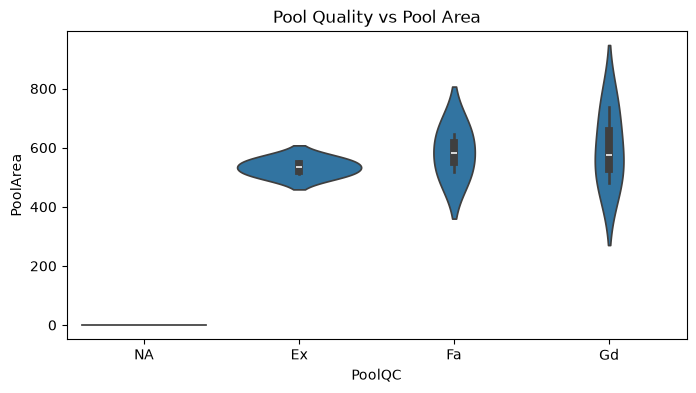

In [22]:
#PoolQC: Calidad de la piscina.
print(f"-- PoolQC ---")
#Visualización de los datos faltantes, cantidad y porcentaje
print(useTrain['PoolQC'].unique())
missing_poolqc = pd.DataFrame(useTrain['PoolQC'].value_counts(dropna=False))
missing_poolqc['percentage(%)'] = np.round(missing_poolqc['count'] / useTrain.shape[0] * 100, 2)
display(missing_poolqc)


PoolQC_missingValuesNumber = useTrain[useTrain['PoolArea'] == 0]['PoolQC'].isna().sum()
print(f'El numero de missing values corresponde a {PoolQC_missingValuesNumber} que es igual al numero de PoolArea = 0')

#Imputación de los datos faltantes
useTrain.loc[:, 'PoolQC'] = useTrain['PoolQC'].fillna('NA')
#Visualización de la relación entre PoolQC y PoolArea graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='PoolQC', y='PoolArea', data=useTrain)
plt.title('Pool Quality vs Pool Area')
plt.show()
#PoolQC: Calidad de la piscina. depende de PoolArea. Si PoolArea es 0, PoolQC es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- MiscFeature ---


,count,percentage(%)
MiscFeature,,
NaN,1406,96.30
Shed,49,3.36
Gar2,2,0.14
Othr,2,0.14
TenC,1,0.07


El numero de missing values corresponde a 1406 que es igual al numero de MiscVal = 0


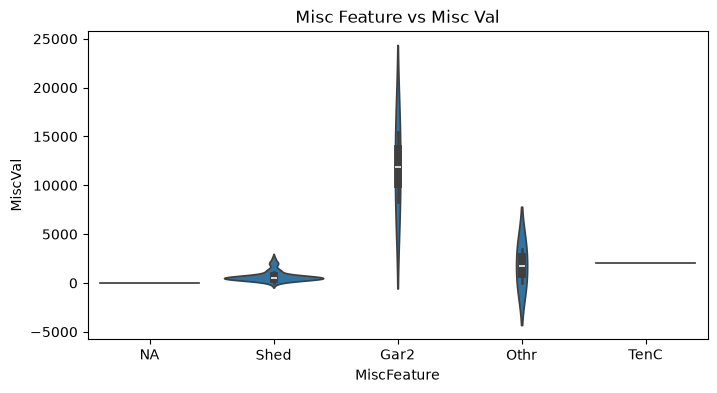

In [23]:
#MiscFeature: Característica miscelánea no cubierta en otras categorías.
print(f"-- MiscFeature ---")
#MiscVal: Valor monetario de la característica miscelánea.
#Visualización de los datos faltantes, cantidad y porcentaje
missing_miscFeature = pd.DataFrame(useTrain['MiscFeature'].value_counts(dropna=False))
missing_miscFeature['percentage(%)'] = np.round(missing_miscFeature['count'] / useTrain.shape[0] * 100, 2)
display(missing_miscFeature)

#visualizar las filas con datos faltantes en MiscFeature y su relación con MiscVal
MiscFeature_missingValuesNumber = useTrain[useTrain['MiscVal'] == 0]['MiscFeature'].isna().sum()
print(f'El numero de missing values corresponde a {MiscFeature_missingValuesNumber} que es igual al numero de MiscVal = 0')
#Imputación de los datos faltantes
useTrain.loc[:, 'MiscFeature'] = useTrain['MiscFeature'].fillna('NA')
#Visualizacion de la relación entre MiscFeature y MiscVal graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='MiscFeature', y='MiscVal', data=useTrain)
plt.title('Misc Feature vs Misc Val')
plt.show()
#MiscFeature: Característica miscelánea no cubierta en otras categorías. Depende de MiscVal. Si MiscVal es 0, MiscFeature es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- Alley ---


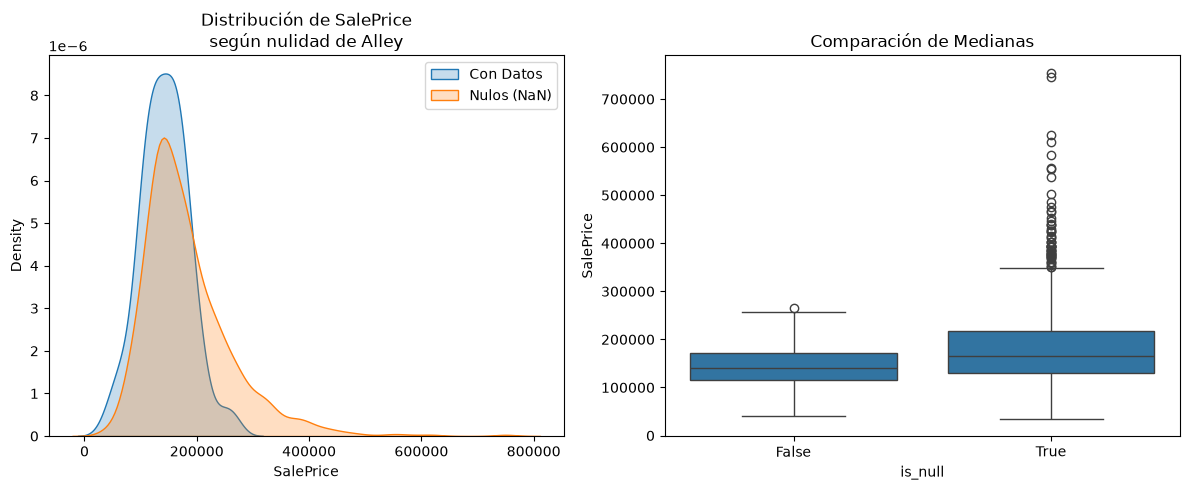

--- Diagnóstico para Alley ---
P-Valor de la prueba Mann-Whitney: 0.0000
Resultado: Diferencia significativa detectada. Es MAR o MNAR (No aleatorio).


In [24]:
#Alley: Tipo de acceso por callejón a la propiedad.
print(f"-- Alley ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_alley = pd.DataFrame(useTrain['Alley'].value_counts(dropna=False))
missing_alley['percentage(%)'] = np.round(missing_alley['count'] / useTrain.shape[0] * 100, 2)
#display(missing_alley)

#visualizar las filas con datos faltantes en Alley
test_mcar(useTrain, 'Alley')
#Se diferencia los precios de las casas con y sin callejón NA. tienen un mas elevado. se imputan con NA
useTrain.loc[:, 'Alley'] = useTrain['Alley'].fillna('NA')

-- Fence ---


,count,percentage(%)
Fence,,
NaN,1179,80.75
MnPrv,157,10.75
GdPrv,59,4.04
GdWo,54,3.70
MnWw,11,0.75


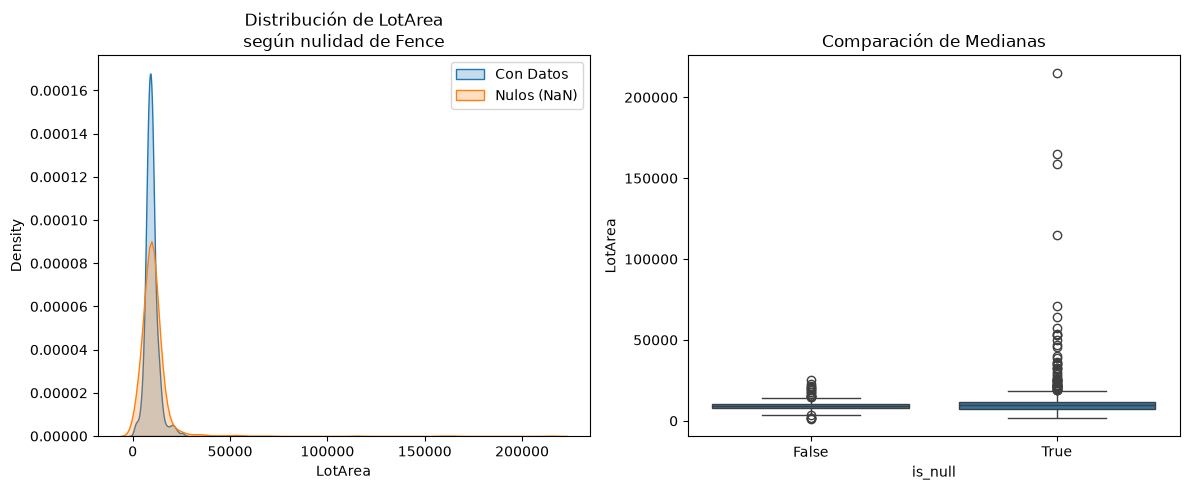

--- Diagnóstico para Fence ---
P-Valor de la prueba Mann-Whitney: 0.1652
Resultado: No hay diferencia significativa. Posible MCAR (Aleatorio).


In [25]:
#Fence: Calidad de la cerca alrededor de la propiedad.
print(f"-- Fence ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_fence = pd.DataFrame(useTrain['Fence'].value_counts(dropna=False))
missing_fence['percentage(%)'] = np.round(missing_fence['count'] / useTrain.shape[0] * 100, 2)
display(missing_fence)
test_mcar(useTrain, 'Fence', 'LotArea')
#Se imputan con NA. Se diferencia los precios de las casas con y sin cerca NA. pero ademas un area de lote mas grande.
useTrain.loc[:, 'Fence'] = useTrain['Fence'].fillna('NA')

In [ ]:
#MasVnrArea: Área de revestimiento de mampostería.
missing_masvnrarea = pd.DataFrame(useTrain['MasVnrArea'].isnull().value_counts(dropna=False))
missing_masvnrarea['percentage(%)'] = np.round(missing_masvnrarea['count'] / useTrain.shape[0] * 100, 2)
display(missing_masvnrarea)

useTrain.loc[:, 'MasVnrArea'] = useTrain['MasVnrArea'].fillna(0)
#Se imputan los missing values con 0.
#El tipo de revestimiento de mampostería (MasVnrType) es missing value, por lo que el área de revestimiento de mampostería (MasVnrArea) es 0. Se puede imputar con 0. No son aleatorias.

,count,percentage(%)
MasVnrArea,,
False,1452,99.45
True,8,0.55


,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


-- MasVnrType ---


,count,percentage(%)
MasVnrType,,
NaN,872,59.73
BrkFace,445,30.48
Stone,128,8.77
BrkCmn,15,1.03


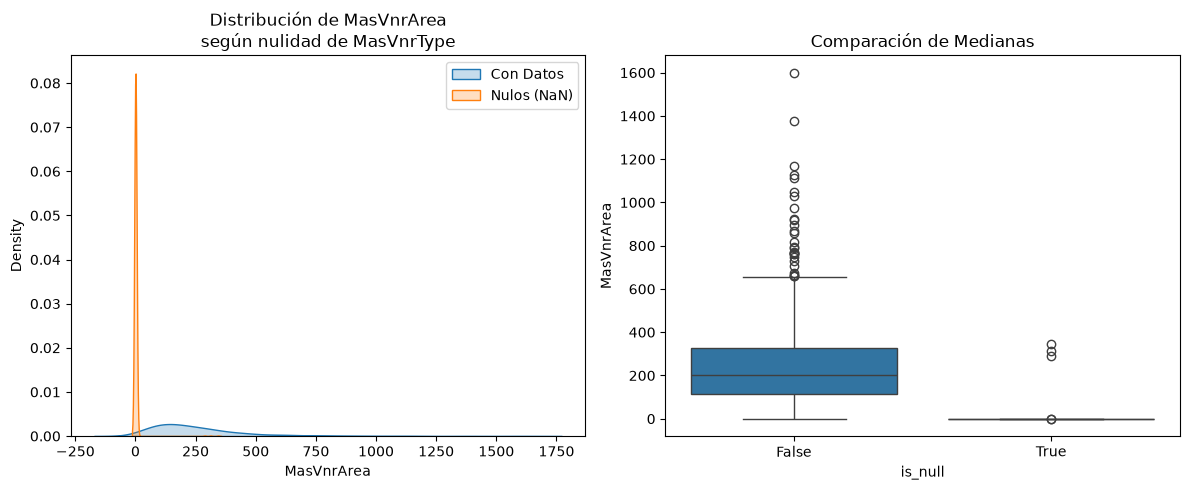

--- Diagnóstico para MasVnrType ---
P-Valor de la prueba Mann-Whitney: nan
Resultado: Diferencia significativa detectada. Es MAR o MNAR (No aleatorio).


MasVnrType  Exterior1st  Exterior2nd
None        VinylSd      VinylSd        2
            HdBoard      HdBoard        1
            Wd Sdng      Wd Sdng        1
            Plywood      Plywood        1
            CemntBd      CmentBd        0
            Wd Sdng      Stone          0
Name: MasVnrArea, dtype: int64

In [27]:
#MasVnrType: Tipo de revestimiento de mampostería.
print(f"-- MasVnrType ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_masvnrtype = pd.DataFrame(useTrain['MasVnrType'].value_counts(dropna=False))
missing_masvnrtype['percentage(%)'] = np.round(missing_masvnrtype['count'] / useTrain.shape[0] * 100, 2)
display(missing_masvnrtype)

test_mcar(useTrain, 'MasVnrType', 'MasVnrArea')
#La densidad de area construida 0, es donde se concentran la mayoría de Area Nula, con excepción de algunos casos.
#Dato que todos los MasVnrArea = 0, MasVnrType = None. Se puede imputar con None. No son aleatorias.
useTrain.loc[:, 'MasVnrType'] = useTrain['MasVnrType'].fillna('None')
display(useTrain[(useTrain['MasVnrType'] == 'None') & (useTrain['MasVnrArea'] != 0)].groupby(['MasVnrType', 'Exterior1st', 'Exterior2nd'])['MasVnrArea'].count().sort_values(ascending=False))

#Viendo la comparativa de revestimientos con el agrupamiendo, se decide dejar estos en None ya que los tipos no se encuentran en la lista de tipos de revestimiento. Se puede imputar con None. No son aleatorias.

In [28]:
#FireplaceQu: Calidad de la chimenea.
print(f"-- FireplaceQu ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_fireplacequ = pd.DataFrame(useTrain['FireplaceQu'].value_counts(dropna=False))
missing_fireplacequ['percentage(%)'] = np.round(missing_fireplacequ['count'] / useTrain.shape[0] * 100, 2)
display(missing_fireplacequ)
#Se da por hecho que si Fireplaces es 0, entonces FireplaceQu es NA
condition_fireplaceQU = (useTrain['Fireplaces'] == 0)
useTrain.loc[condition_fireplaceQU, 'FireplaceQu'] = 'NA';
#Se imputa bajo la condicion que si Fireplaces es 0, entonces FireplaceQu es NA. No son aleatorias.

-- FireplaceQu ---


,count,percentage(%)
FireplaceQu,,
NaN,690,47.26
Gd,380,26.03
TA,313,21.44
Fa,33,2.26
Ex,24,1.64
Po,20,1.37


In [29]:
#GarageArea: Tamaño del garaje en pies cuadrados.
#GarageFinish: Acabado interior del garaje.
#GarageQual: Calidad del garaje.
#GarageType: Ubicación del garaje.
#GarageCond: Condición del garaje.
#GarageYrBlt: Año de construcción del garaje.
condition_garageArea = (useTrain['GarageArea'] == 0)
#Siempre que GarageArea es 0, entonces GarageFinish, GarageQual, GarageType, GarageCond y GarageYrBlt son NA. Se puede imputar con NA. No son aleatorias.
useTrain.loc[condition_garageArea, 'GarageFinish'] = 'NA'
useTrain.loc[condition_garageArea, 'GarageQual'] = 'NA'
useTrain.loc[condition_garageArea, 'GarageType'] = 'NA'
useTrain.loc[condition_garageArea, 'GarageCond'] = 'NA'
useTrain.loc[condition_garageArea, 'GarageYrBlt'] = 0
useTrain[(useTrain['GarageArea'] == 0)][['GarageArea', 'GarageFinish', 'GarageQual', 'GarageType', 'GarageCond', 'GarageYrBlt']]

,GarageArea,GarageFinish,GarageQual,GarageType,GarageCond,GarageYrBlt
39,0,NA,NA,NA,NA,0.0
48,0,NA,NA,NA,NA,0.0
78,0,NA,NA,NA,NA,0.0
88,0,NA,NA,NA,NA,0.0
89,0,NA,NA,NA,NA,0.0
...,...,...,...,...,...,...
1349,0,NA,NA,NA,NA,0.0
1407,0,NA,NA,NA,NA,0.0
1449,0,NA,NA,NA,NA,0.0
1450,0,NA,NA,NA,NA,0.0


In [30]:
#BsmtFinType2: Calificación del área terminada del sótano (si hay varios tipos).
#BsmtExposure: Se refiere a las paredes del sótano a nivel de jardín o con salida.
#BsmtCond: Evalúa la condición general del sótano.
#BsmtQual: Evalúa la altura del sótano.
#BsmtFinType1: Calificación del área terminada del sótano.
condition_bsmt = (useTrain['TotalBsmtSF'] == 0)
useTrain.loc[condition_bsmt, 'BsmtFinType1'] = 'NA'
useTrain.loc[condition_bsmt, 'BsmtFinType2'] = 'NA'
useTrain.loc[condition_bsmt, 'BsmtExposure'] = 'NA'
useTrain.loc[condition_bsmt, 'BsmtCond'] = 'NA'
useTrain.loc[condition_bsmt, 'BsmtQual'] = 'NA'
useTrain[(useTrain['TotalBsmtSF'] == 0)][['TotalBsmtSF', 'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual']]

,TotalBsmtSF,BsmtFinType1,BsmtFinType2,BsmtExposure,BsmtCond,BsmtQual
17,0,NA,NA,NA,NA,NA
39,0,NA,NA,NA,NA,NA
90,0,NA,NA,NA,NA,NA
102,0,NA,NA,NA,NA,NA
156,0,NA,NA,NA,NA,NA
182,0,NA,NA,NA,NA,NA
259,0,NA,NA,NA,NA,NA
342,0,NA,NA,NA,NA,NA
362,0,NA,NA,NA,NA,NA
371,0,NA,NA,NA,NA,NA


In [31]:
#Si TotalBsmtSF es diferente 0, tiene sotano
#Si BsmtFinSF1 es diferente 0, tiene sotano tipo 1 iniciado
#Si BsmtFinSF2 es diferente 0, tiene sotano tipo 2 iniciado
#Si BsmtFinSF1 es diferente 0 y BsmtUnfSF es diferente 0, tiene sotano tipo 1 iniciado y sin terminar
#Si BsmtFinSF2 es diferente 0 y BsmtUnfSF es diferente 0, tiene sotano tipo 2 iniciado y sin terminar
condition_bsmtFinType1_unf = (useTrain['BsmtFinSF1'] != 0) & (useTrain['BsmtUnfSF'] != 0) & (useTrain['TotalBsmtSF'] != 0)
useTrain.loc[condition_bsmtFinType1_unf, 'BsmtFinType1'] = 'Unf'
condition_bsmtFinType2_unf = (useTrain['BsmtFinSF2'] != 0) & (useTrain['BsmtUnfSF'] != 0) & (useTrain['TotalBsmtSF'] != 0)
useTrain.loc[condition_bsmtFinType2_unf, 'BsmtFinType2'] = 'Unf'

In [32]:
#Al no encontrar relacion con otras features, se imputo con la media de las features Street, LotShape, LandContour y Neighborhood. Si no se encuentra la media, se imputo con la mediana.
useTrain['LotFrontage'] = useTrain['LotFrontage'].fillna(
    useTrain.groupby(['Street', 'LotShape', 'LandContour', 'Neighborhood'])['LotFrontage'].transform('mean')).fillna(useTrain['LotFrontage'].median())

In [33]:
#Ultimas features con missing values, se imputan con la moda.
useTrain['Electrical'] = useTrain['Electrical'].fillna(useTrain['Electrical'].mode().iloc[0])
useTrain['BsmtExposure'] = useTrain['BsmtExposure'].fillna(useTrain['BsmtExposure'].mode().iloc[0])

In [34]:
useTrain = useTrain.reset_index(drop=True)
#Analisis de features con missing values
useTrain.to_csv('../data/processed/train_missing_values.csv', index=False)